Setup & Install

In [1]:
!pip install kagglehub --quiet

In [2]:
import kagglehub
from pathlib import Path
import os
import random

In [15]:
import zipfile
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

 Step 2 — Download Dataset from Kaggle


In [4]:
# ==============================
# 2. Download Dataset
# ==============================

# Download dataset from Kaggle
path = kagglehub.dataset_download("moltean/fruits")

# Root directory
root_dir = Path(path)

print("Dataset path :", root_dir)

# Show available dataset versions
dataset_versions = sorted([d for d in os.listdir(root_dir) if not d.startswith('.')])
print("Available dataset versions:", dataset_versions)

# Select the version we will use
DATASET_NAME = "fruits-360_100x100"
DATA_DIR = root_dir / DATASET_NAME / "fruits-360"

print("\nUsing dataset:", DATASET_NAME)
print("DATA_DIR:", DATA_DIR)

Using Colab cache for faster access to the 'fruits' dataset.
Dataset path : /kaggle/input/fruits
Available dataset versions: ['fruits-360_100x100', 'fruits-360_3-body-problem', 'fruits-360_meta', 'fruits-360_multi', 'fruits-360_original-size']

Using dataset: fruits-360_100x100
DATA_DIR: /kaggle/input/fruits/fruits-360_100x100/fruits-360


In [5]:
# ==============================
# 3. Define Train & Test Paths
# ==============================

TRAIN_DIR = DATA_DIR / "Training"
TEST_DIR  = DATA_DIR / "Test"

print("Train path:", TRAIN_DIR)
print("Test path :", TEST_DIR)

Train path: /kaggle/input/fruits/fruits-360_100x100/fruits-360/Training
Test path : /kaggle/input/fruits/fruits-360_100x100/fruits-360/Test


In [6]:
# Set dataset paths
DATA_DIR  = root_dir / "fruits-360_100x100" / "fruits-360"
TRAIN_DIR = DATA_DIR / "Training"
TEST_DIR  = DATA_DIR / "Test"

# List valid class directories
# Only directories are counted (ignore hidden files)
class_names_train = sorted([d for d in os.listdir(TRAIN_DIR) if (TRAIN_DIR / d).is_dir()])
class_names_test  = sorted([d for d in os.listdir(TEST_DIR)  if (TEST_DIR / d).is_dir()])

# Count images safely
# Training images count
total_train = sum(len([f for f in os.listdir(TRAIN_DIR / c) if not f.startswith('.')])
                  for c in class_names_train)

# Test images count (some classes might be missing in TEST_DIR)
total_test = 0
for c in class_names_train:  # iterate over training classes
    folder_path = TEST_DIR / c
    if folder_path.is_dir():
        total_test += len([f for f in os.listdir(folder_path) if not f.startswith('.')])

# Print dataset info
print(f"Total classes in train: {len(class_names_train)}")
print(f"Total classes in test : {len(class_names_test)}")
print(f"Training images       : {total_train}")
print(f"Test images           : {total_test}")
print(f"Sample train classes  : {class_names_train[:8]}")

# Unified class_names variable
# This is useful for visualization or metrics later
class_names = class_names_train

Total classes in train: 257
Total classes in test : 257
Training images       : 135071
Test images           : 44863
Sample train classes  : ['Almonds 1', 'Apple 10', 'Apple 11', 'Apple 12', 'Apple 13', 'Apple 14', 'Apple 17', 'Apple 18']


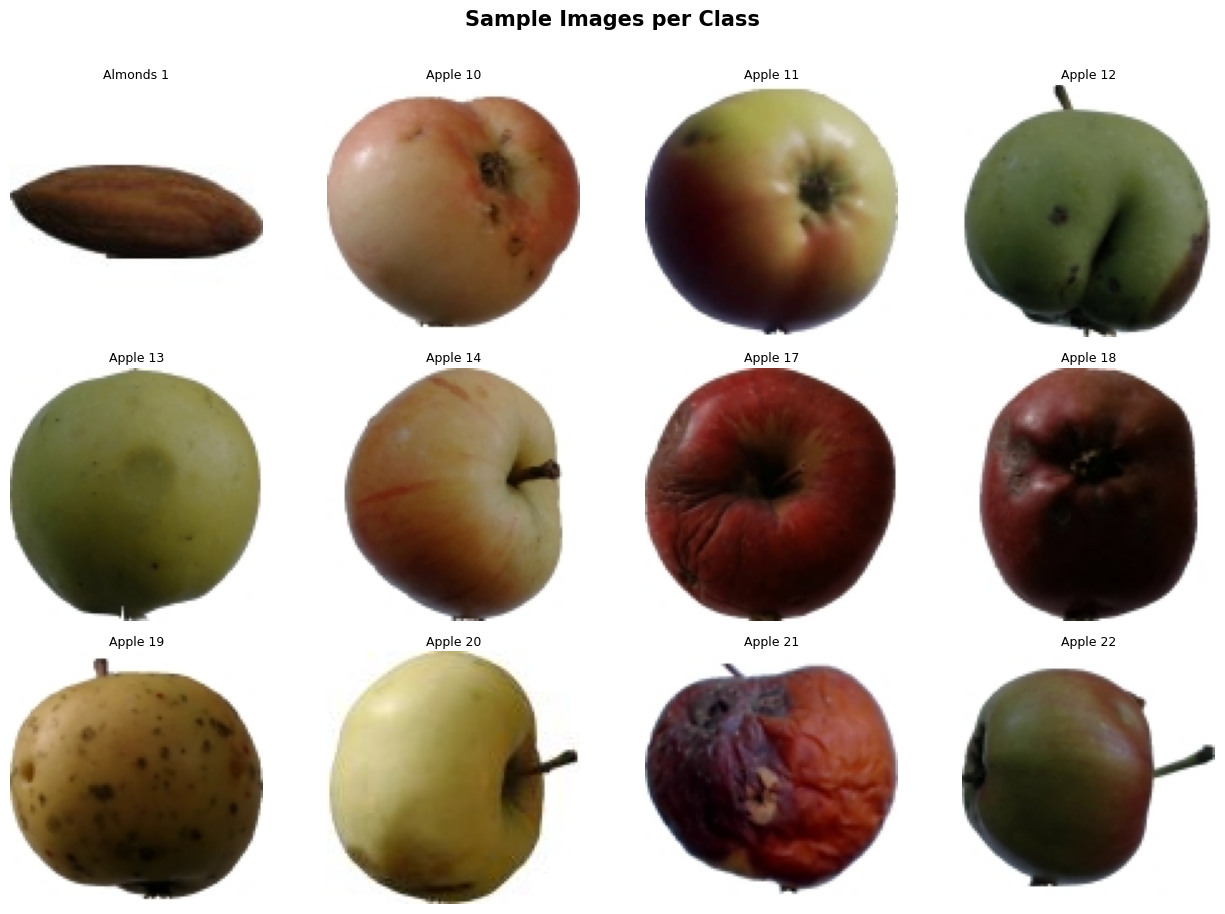

In [7]:
# Display one random sample image from each of the first 12 classes
fig, axes = plt.subplots(3, 4, figsize=(13, 9))
fig.suptitle("Sample Images per Class", fontsize=15, fontweight='bold', y=1.01)

for i, ax in enumerate(axes.flat):
    class_folder = TRAIN_DIR / class_names[i]
    img_file     = random.choice([f for f in os.listdir(class_folder) if not f.startswith('.')])
    img          = plt.imread(class_folder / img_file)

    ax.imshow(img)
    ax.set_title(class_names[i], fontsize=9, pad=4)
    ax.axis('off')

plt.tight_layout()
plt.show()

Preprocess & Augment


In [8]:
# Configuration
IMG_SIZE    = (100, 100)   # match the dataset image dimensions
BATCH_SIZE  = 32
EPOCHS      = 15
NUM_CLASSES = 10           # change to num_classes to train on all fruits

selected_classes = class_names[:NUM_CLASSES]
print("Classes selected for training:", selected_classes)

Classes selected for training: ['Almonds 1', 'Apple 10', 'Apple 11', 'Apple 12', 'Apple 13', 'Apple 14', 'Apple 17', 'Apple 18', 'Apple 19', 'Apple 20']


In [9]:
IMG_SIZE    = (100, 100)   # size of images in dataset
BATCH_SIZE  = 32
EPOCHS      = 15
NUM_CLASSES = 10           # number of classes to train on

# select the classes you want to train on
selected_classes = class_names[:NUM_CLASSES]
print("Classes selected for training:", selected_classes)
# -----------------------------
# ImageDataGenerator Configuration
# -----------------------------

# Training generator — rescale + moderate augmentation
train_datagen = ImageDataGenerator(
    rescale = 1.0 / 255,
    rotation_range = 20,        # random rotation up to +-20 degrees
    width_shift_range = 0.1,    # random horizontal shift
    height_shift_range = 0.1,   # random vertical shift
    zoom_range = 0.2,           # random zoom up to 20%
    horizontal_flip = True,      # randomly flip images left/right
    fill_mode = 'nearest',       # fill in new pixels after transformations
    validation_split = 0.2      # 20% of training data used for validation
)

# Validation generator — same preprocessing as train but no shuffle augmentation
val_datagen = ImageDataGenerator(
    rescale = 1.0 / 255,
    validation_split = 0.2
)

# Test generator — rescale only, no augmentation
test_datagen = ImageDataGenerator(rescale = 1.0 / 255)

# -----------------------------
# Flow from directories
# -----------------------------

# Training set
train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size = IMG_SIZE,
    batch_size = BATCH_SIZE,
    classes = selected_classes,
    class_mode = 'categorical',
    shuffle = True,
    subset = 'training'           # use the training subset
)

# Validation set
val_generator = val_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size = IMG_SIZE,
    batch_size = BATCH_SIZE,
    classes = selected_classes,
    class_mode = 'categorical',
    shuffle = False,
    subset = 'validation'         # use the validation subset
)

# Test set
test_generator = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size = IMG_SIZE,
    batch_size = BATCH_SIZE,
    classes = selected_classes,
    class_mode = 'categorical',
    shuffle = False
)

Classes selected for training: ['Almonds 1', 'Apple 10', 'Apple 11', 'Apple 12', 'Apple 13', 'Apple 14', 'Apple 17', 'Apple 18', 'Apple 19', 'Apple 20']
Found 4610 images belonging to 10 classes.
Found 1147 images belonging to 10 classes.
Found 1909 images belonging to 10 classes.


Build the CNN Model

```
Input (100 x 100 x 3)
  -> Conv2D(32)  + ReLU  + BatchNorm + MaxPool   <- detect edges & colors
  -> Conv2D(64)  + ReLU  + BatchNorm + MaxPool   <- detect shapes & textures
  -> Conv2D(128) + ReLU  + BatchNorm + MaxPool   <- detect fruit-level patterns
  -> Conv2D(256) + ReLU  + BatchNorm + MaxPool   <- optional deeper features
  -> Flatten
  -> Dense(256)  + ReLU  + Dropout(0.5)
  -> Dense(128)  + ReLU  + Dropout(0.5)
  -> Dense(NUM_CLASSES) + Softmax                 <- output class probabilities
```

In [10]:
def build_improved_cnn(num_classes, input_shape=(100, 100, 3)):
    model = models.Sequential([
        # Block 1: detect basic features
        layers.Conv2D(32, (3, 3), activation='relu', input_shape=input_shape),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2, 2),

        # Block 2: intermediate features
        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2, 2),

        # Block 3: high-level features
        layers.Conv2D(128, (3, 3), activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2, 2),

        # Block 4: optional deeper block for more complexity
        layers.Conv2D(256, (3, 3), activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2, 2),

        # Classifier head
        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax')
    ])

    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

# Build the model
model = build_improved_cnn(NUM_CLASSES)
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 98, 98, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 98, 98, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 49, 49, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 47, 47, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 47, 47, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 23, 23, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 21, 21, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 21, 21, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 10, 10, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     1,048,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,473,354 (5.62 MB)

 Trainable params: 1,472,394 (5.62 MB)

 Non-trainable params: 960 (3.75 KB)

Two callbacks are used during training:

| Callback | Purpose |
|---|---|
| `EarlyStopping` | Stops training if validation accuracy stops improving |
| `ModelCheckpoint` | Saves the best model weights automatically |

In [11]:
# Callbacks
early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=3,                  # stop after 3 epochs with no improvement
    restore_best_weights=True,   # restore model weights from best epoch
    verbose=2
)

checkpoint = ModelCheckpoint(
    filepath='best_model.keras', # file to save the best model
    monitor='val_accuracy',
    save_best_only=True,         # save only the best model
    verbose=2
)

# Training
history = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=test_generator,
    callbacks=[early_stop, checkpoint],
    verbose=2
)

Epoch 1/15

Epoch 1: val_accuracy improved from None to 0.12101, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
145/145 - 73s - 503ms/step - accuracy: 0.6341 - loss: 1.3406 - val_accuracy: 0.1210 - val_loss: 8.5322
Epoch 2/15

Epoch 2: val_accuracy improved from 0.12101 to 0.14458, saving model to best_model.keras

Epoch 2: finished saving model to best_model.keras
145/145 - 21s - 148ms/step - accuracy: 0.8501 - loss: 0.5354 - val_accuracy: 0.1446 - val_loss: 8.2104
Epoch 3/15

Epoch 3: val_accuracy improved from 0.14458 to 0.64746, saving model to best_model.keras

Epoch 3: finished saving model to best_model.keras
145/145 - 19s - 132ms/step - accuracy: 0.9104 - loss: 0.3415 - val_accuracy: 0.6475 - val_loss: 2.8447
Epoch 4/15

Epoch 4: val_accuracy improved from 0.64746 to 0.95862, saving model to best_model.keras

Epoch 4: finished saving model to best_model.keras
145/145 - 20s - 141ms/step - accuracy: 0.9258 - loss: 0.2790 - val_accuracy: 0.958

 - Callbacks to save the best model and stop training early to prevent overfitting.
 - EarlyStopping restores the best weights based on validation accuracy.
 -  ModelCheckpoint saves the best model during training.

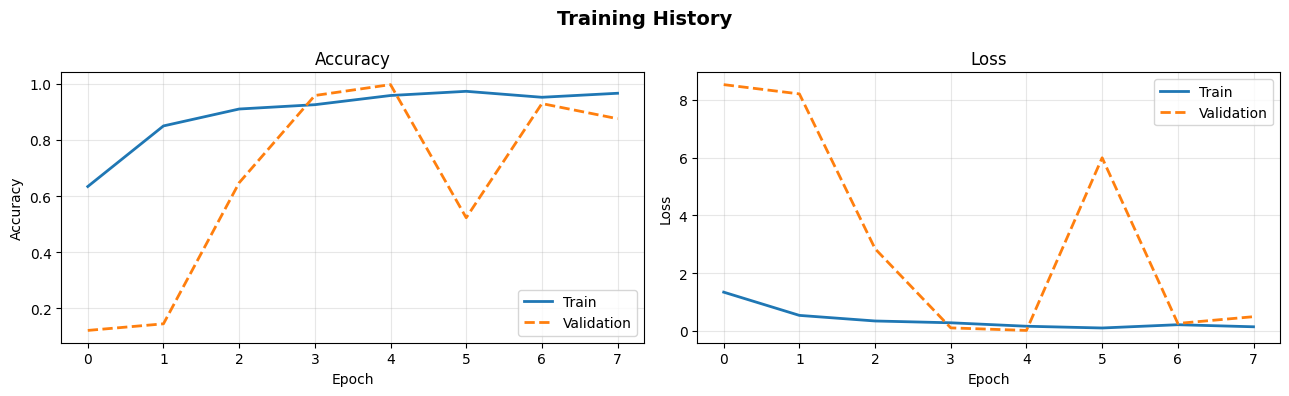

In [12]:
# Plot accuracy and loss curves for both training and validation
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle("Training History", fontsize=14, fontweight='bold')

# Accuracy
ax1.plot(history.history['accuracy'],  label='Train', linewidth=2)
ax1.plot(history.history['val_accuracy'], label='Validation', linewidth=2, linestyle='--')
ax1.set_title('Accuracy')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Loss
ax2.plot(history.history['loss'], label='Train', linewidth=2)
ax2.plot(history.history['val_loss'], label='Validation', linewidth=2, linestyle='--')
ax2.set_title('Loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [13]:
# Load the best saved model and compute final accuracy on the test set
best_model = tf.keras.models.load_model('best_model.keras')

test_loss, test_acc = best_model.evaluate(test_generator, verbose=0)
print(f"Test Accuracy : {test_acc * 100:.2f}%")
print(f"Test Loss     : {test_loss:.4f}")

Test Accuracy : 99.74%
Test Loss     : 0.0141


60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step


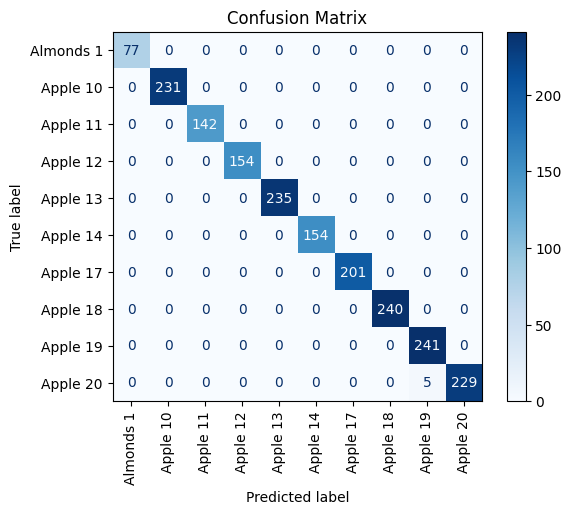

In [16]:
# Get true labels and predictions
y_true = test_generator.classes  # true class indices
y_pred = best_model.predict(test_generator)
y_pred = np.argmax(y_pred, axis=1)  # convert probabilities to class indices

# Plot the confusion matrix
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=selected_classes)
disp.plot(cmap=plt.cm.Blues, xticks_rotation='vertical')
plt.title("Confusion Matrix")
plt.show()

Upload a fruit image:


Saving apple.jpg to apple.jpg


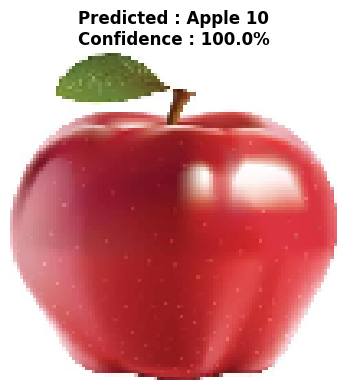


Top 3 predictions:
-----------------------------------
  1. Apple 10                  100.00%
  2. Apple 11                  0.00%
  3. Apple 17                  0.00%


In [17]:
from google.colab import files
from tensorflow.keras.preprocessing import image as keras_image

# Upload a fruit image from your device
print("Upload a fruit image:")
uploaded_img = files.upload()
img_filename = list(uploaded_img.keys())[0]

# Load and preprocess the image to match the model input shape
img = keras_image.load_img(img_filename, target_size=IMG_SIZE)
img_array = keras_image.img_to_array(img) / 255.0    # rescale to [0, 1]
img_array = np.expand_dims(img_array, axis=0)         # add batch dimension -> (1, 100, 100, 3)

# Run the prediction
predictions = best_model.predict(img_array, verbose=0)
predicted_idx = np.argmax(predictions[0])
confidence = predictions[0][predicted_idx] * 100

# Display the image with the predicted label
plt.figure(figsize=(4, 4))
plt.imshow(img)
plt.axis('off')
plt.title(f"Predicted : {selected_classes[predicted_idx]}\nConfidence : {confidence:.1f}%",fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# Print the top 3 predictions with confidence scores
print("\nTop 3 predictions:")
print("-" * 35)
top3 = np.argsort(predictions[0])[::-1][:3]
for rank, idx in enumerate(top3, 1):
    print(f"  {rank}. {selected_classes[idx]:<25} {predictions[0][idx]*100:.2f}%")